# 03 — Gini mes a mes

Gini de los tres modelos en cada `CODMES` (jun 2023 – may 2024), para el slide de comparación de modelos:

1. **Logística WOE (18 variables)**: artefacto guardado `model/modelo_logistico_woe.pkl`, sin reentrenar.
2. **CatBoost benchmark (45 variables)**: el modelo no se guardó, así que se **replica exactamente** el código de
   `03_benchmark_catboost.ipynb` (mismas variables, misma regla de categóricas aprendida en TRAIN, mismos
   hiperparámetros, semilla 42 y early stopping en VALIDATION). No se cambia nada del modelo. Se fija
   `thread_count=16`, el número de hilos con el que se obtuvieron las cifras oficiales (ver README).
3. **Modelo actual del banco**: columna `PREDICCION_MODELO_ANTERIOR`.

`Gini = 2·AUC − 1` con `sklearn.metrics.roc_auc_score`, calculado por separado en cada mes.

Antes de graficar se verifica que el Gini agregado por muestra coincida con el slide actual (tolerancia 0.002).
Si no coincide, el notebook se detiene.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

ROOT = Path.cwd().resolve()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from predict import cargar_modelo, predecir_pd  # sin cambios

OUT_DIR = ROOT / "impacto" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CFG = json.loads((ROOT / "config" / "modelo_config.json").read_text(encoding="utf-8"))
TARGET, TIEMPO = CFG["target"], CFG["time_column"]
SCORE_BANCO = "PREDICCION_MODELO_ANTERIOR"
RANDOM_SEED = 42
N_REPLICAS = 500
TOLERANCIA = 0.002

# Gini agregado del slide actual (verificación obligatoria)
REFERENCIA = {
    "woe":      {"TRAIN": 0.599, "VALIDATION": 0.582, "OOT": 0.593},
    "catboost": {"TRAIN": 0.726, "VALIDATION": 0.616, "OOT": 0.609},
    "banco":    {"TRAIN": 0.476, "VALIDATION": 0.420, "OOT": 0.445},
}
MODELOS = ["woe", "catboost", "banco"]
MUESTRAS = ["TRAIN", "VALIDATION", "OOT"]


def gini(y, score):
    return 2 * roc_auc_score(y, score) - 1

## 1. Base y split temporal (de `config/modelo_config.json`)

In [2]:
df = pd.read_parquet(ROOT / "data" / "raw" / "base_analytics_lab_061628.parquet")

df["muestra"] = np.select(
    [df[TIEMPO] <= CFG["train_max"], df[TIEMPO].isin(CFG["validation_months"]), df[TIEMPO].isin(CFG["oot_months"])],
    MUESTRAS,
    default="FUERA",
)
assert (df["muestra"] != "FUERA").all()

display(df.groupby("muestra", sort=False).agg(n=(TARGET, "size"), malos=(TARGET, "sum"), meses=(TIEMPO, "nunique")))

,n,malos,meses
muestra,,,
TRAIN,38462,6161,8
VALIDATION,10583,1582,2
OOT,10955,1548,2


## 2. Logística WOE: artefacto guardado, sin reentrenar

In [3]:
artefacto = cargar_modelo(ROOT / "model" / "modelo_logistico_woe.pkl")
pd_woe = predecir_pd(df, artefacto)
assert pd_woe.index.equals(df.index), "predecir_pd cambió el orden de las filas"
df["score_woe"] = pd_woe["PD"].to_numpy()

[INFO] converting into woe values ...


## 3. Modelo actual del banco: dirección del score

Se revisa que un valor mayor de `PREDICCION_MODELO_ANTERIOR` signifique más riesgo (AUC > 0.5). **No se invierte**:
si el AUC sale menor a 0.5 el notebook se detiene. Las filas con score vacío se excluyen solo para este modelo.

In [4]:
df["score_banco"] = df[SCORE_BANCO].astype(float)
ok = df["score_banco"].notna()

print("Score promedio por TARGET:")
print(df.groupby(TARGET)["score_banco"].mean().round(4).to_string())
print(f"\nFilas sin score del banco: {(~ok).sum()} → por mes:", df.loc[~ok, TIEMPO].value_counts().sort_index().to_dict())

auc_banco = roc_auc_score(df.loc[ok, TARGET], df.loc[ok, "score_banco"])
print(f"AUC global del banco: {auc_banco:.4f}")
assert auc_banco > 0.5, "AUC del banco < 0.5: avisar antes de invertir el score"
print("Dirección correcta: mayor valor = mayor riesgo")

Score promedio por TARGET:
TARGET
0    0.2707
1    0.4452

Filas sin score del banco: 5 → por mes: {202306: 1, 202309: 2, 202402: 1, 202403: 1}
AUC global del banco: 0.7304
Dirección correcta: mayor valor = mayor riesgo


## 4. CatBoost: réplica exacta de `03_benchmark_catboost.ipynb`

Mismo código, mismas decisiones. Solo se cambia el nombre de los objetos de las muestras.

> **Hilos de CPU.** CatBoost varía con el número de hilos: el notebook 03 no lo fija y usa todos los núcleos.
> Sin fijarlo, en un equipo de 20 hilos el early stopping para en la iteración 948 (en vez de 861) y el Gini TRAIN
> sale 0.734 en lugar de 0.726. Las cifras oficiales se obtuvieron con 16 hilos (README), así que se fija
> `thread_count=16` para reproducir el mismo modelo. No cambia ningún hiperparámetro.

In [5]:
variables_excluir = [TARGET, TIEMPO, "PREDICCION_MODELO_ANTERIOR", "PROXY_TARGET_6M"]
base_original = df.drop(columns=["muestra", "score_woe", "score_banco"])
variables_catboost = [c for c in base_original.columns if c not in variables_excluir]

train = base_original[df["muestra"] == "TRAIN"]
validation = base_original[df["muestra"] == "VALIDATION"]

# Regla del notebook 03: <= 20 categorías en TRAIN → categórica
variables_categoricas = [v for v in variables_catboost if train[v].nunique(dropna=False) <= 20]
variables_numericas = [v for v in variables_catboost if v not in variables_categoricas]
print("Predictores:", len(variables_catboost), "| categóricas:", len(variables_categoricas),
      "| numéricas:", len(variables_numericas))


def preparar_catboost(base):
    X = base[variables_catboost].copy()
    for variable in variables_categoricas:
        X[variable] = X[variable].astype("object").where(X[variable].notna(), "__MISSING__").astype(str)
    for variable in variables_numericas:
        X[variable] = pd.to_numeric(X[variable], errors="coerce")
    return X


modelo_catboost = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    l2_leaf_reg=5,
    random_seed=RANDOM_SEED,
    thread_count=16,  # hilos de las cifras oficiales (README); no es un hiperparámetro
    allow_writing_files=False,
    verbose=100,
)
modelo_catboost.fit(
    preparar_catboost(train), train[TARGET].astype(int),
    cat_features=variables_categoricas,
    eval_set=(preparar_catboost(validation), validation[TARGET].astype(int)),
    early_stopping_rounds=80,
    use_best_model=True,
)
print("Mejor iteración:", modelo_catboost.get_best_iteration(), "(notebook 03: 861)")

df["score_catboost"] = modelo_catboost.predict_proba(preparar_catboost(base_original))[:, 1]

Predictores: 45 | categóricas: 19 | numéricas: 26


0:	test: 0.7099247	best: 0.7099247 (0)	total: 259ms	remaining: 4m 18s


100:	test: 0.7964016	best: 0.7964016 (100)	total: 12s	remaining: 1m 47s


200:	test: 0.8019708	best: 0.8019708 (200)	total: 25.1s	remaining: 1m 39s


300:	test: 0.8048399	best: 0.8048399 (300)	total: 37.8s	remaining: 1m 27s


...

600:	test: 0.8070965	best: 0.8071177 (598)	total: 1m 4s	remaining: 43.1s


700:	test: 0.8072976	best: 0.8073382 (694)	total: 1m 10s	remaining: 30.1s


800:	test: 0.8078527	best: 0.8078599 (798)	total: 1m 15s	remaining: 18.8s


900:	test: 0.8079875	best: 0.8080925 (861)	total: 1m 21s	remaining: 8.9s


Stopped by overfitting detector  (80 iterations wait)

bestTest = 0.8080925409
bestIteration = 861

Shrink model to first 862 iterations.
Mejor iteración: 861 (notebook 03: 861)


## 5. Verificación obligatoria: Gini agregado vs slide actual

Tolerancia 0.002. Si algún modelo no coincide, el notebook se detiene aquí y no se grafica.

In [6]:
filas = []
for muestra in MUESTRAS:
    d = df[df["muestra"] == muestra]
    for m in MODELOS:
        v = d[f"score_{m}"].notna()
        g = gini(d.loc[v, TARGET], d.loc[v, f"score_{m}"])
        filas.append({"modelo": m, "muestra": muestra, "gini": g,
                      "slide": REFERENCIA[m][muestra], "diferencia": g - REFERENCIA[m][muestra]})

verificacion = pd.DataFrame(filas)
verificacion["ok"] = verificacion["diferencia"].abs() <= TOLERANCIA
display(verificacion.round(4))
assert verificacion["ok"].all(), "Gini agregado no coincide con el slide:\n" + verificacion[~verificacion["ok"]].to_string()
print("Verificación OK: los 9 Gini coinciden con el slide (±0.002)")

,modelo,muestra,gini,slide,diferencia,ok
0,woe,TRAIN,0.5990,0.599,0.0000,True
1,catboost,TRAIN,0.7262,0.726,0.0002,True
2,banco,TRAIN,0.4759,0.476,-0.0001,True
3,woe,VALIDATION,0.5816,0.582,-0.0004,True
4,catboost,VALIDATION,0.6162,0.616,0.0002,True
5,banco,VALIDATION,0.4204,0.420,0.0004,True
6,woe,OOT,0.5927,0.593,-0.0003,True
7,catboost,OOT,0.6091,0.609,0.0001,True
8,banco,OOT,0.4446,0.445,-0.0004,True


Verificación OK: los 9 Gini coinciden con el slide (±0.002)


## 6. Gini mensual con intervalo bootstrap al 95%

500 réplicas por mes, semilla 42, percentiles 2.5 y 97.5. Cada réplica remuestrea los mismos clientes para los tres
modelos (bootstrap pareado), así las bandas son comparables entre modelos.

In [7]:
rng = np.random.default_rng(RANDOM_SEED)
filas = []
for codmes, d in df.groupby(TIEMPO):
    y = d[TARGET].to_numpy()
    idx = rng.integers(0, len(d), size=(N_REPLICAS, len(d)))
    fila = {"CODMES": codmes, "muestra": d["muestra"].iat[0], "n": len(d), "malos": int(y.sum())}
    for m in MODELOS:
        s = d[f"score_{m}"].to_numpy()
        v = ~np.isnan(s)
        fila[f"gini_{m}"] = gini(y[v], s[v])
        boot = [gini(y[i][v[i]], s[i][v[i]]) for i in idx]
        fila[f"gini_{m}_ic95_inf"], fila[f"gini_{m}_ic95_sup"] = np.percentile(boot, [2.5, 97.5])
    filas.append(fila)

columnas = (["CODMES", "muestra", "n", "malos"] + [f"gini_{m}" for m in MODELOS]
            + [f"gini_{m}_ic95_{l}" for m in MODELOS for l in ("inf", "sup")])
gini_mensual = pd.DataFrame(filas)[columnas]  # sin redondear: el gráfico y el resumen leen de aquí
gini_mensual.round(4).to_csv(OUT_DIR / "gini_mensual.csv", index=False)
display(gini_mensual.round(4))

,CODMES,muestra,n,malos,gini_woe,gini_catboost,gini_banco,gini_woe_ic95_inf,gini_woe_ic95_sup,gini_catboost_ic95_inf,gini_catboost_ic95_sup,gini_banco_ic95_inf,gini_banco_ic95_sup
0,202306,TRAIN,4340,642,0.5606,0.7076,0.4618,0.5263,0.5978,0.6775,0.7366,0.4247,0.5015
1,202307,TRAIN,4436,687,0.6075,0.7472,0.5266,0.5752,0.6437,0.7168,0.7760,0.4884,0.5642
2,202308,TRAIN,4595,729,0.5986,0.7340,0.4891,0.5638,0.6359,0.6999,0.7638,0.4461,0.5291
3,202309,TRAIN,4742,757,0.6298,0.7495,0.5188,0.5929,0.6630,0.7207,0.7783,0.4822,0.5568
4,202310,TRAIN,4875,777,0.6044,0.7277,0.4693,0.5749,0.6383,0.6997,0.7545,0.4304,0.5049
5,202311,TRAIN,5042,829,0.5988,0.7142,0.4548,0.5630,0.6337,0.6806,0.7432,0.4171,0.4918
6,202312,TRAIN,5179,884,0.6029,0.7273,0.4520,0.5688,0.6349,0.6945,0.7556,0.4145,0.4872
7,202401,TRAIN,5253,856,0.5871,0.7052,0.4454,0.5506,0.6195,0.6727,0.7311,0.4049,0.4788
8,202402,VALIDATION,5263,802,0.5790,0.6185,0.4092,0.5421,0.6137,0.5839,0.6508,0.3681,0.4456
9,202403,VALIDATION,5320,780,0.5848,0.6140,0.4320,0.5523,0.6173,0.5839,0.6468,0.3967,0.4669


## 7. Gráfico para el slide (1920×1080, sin título)

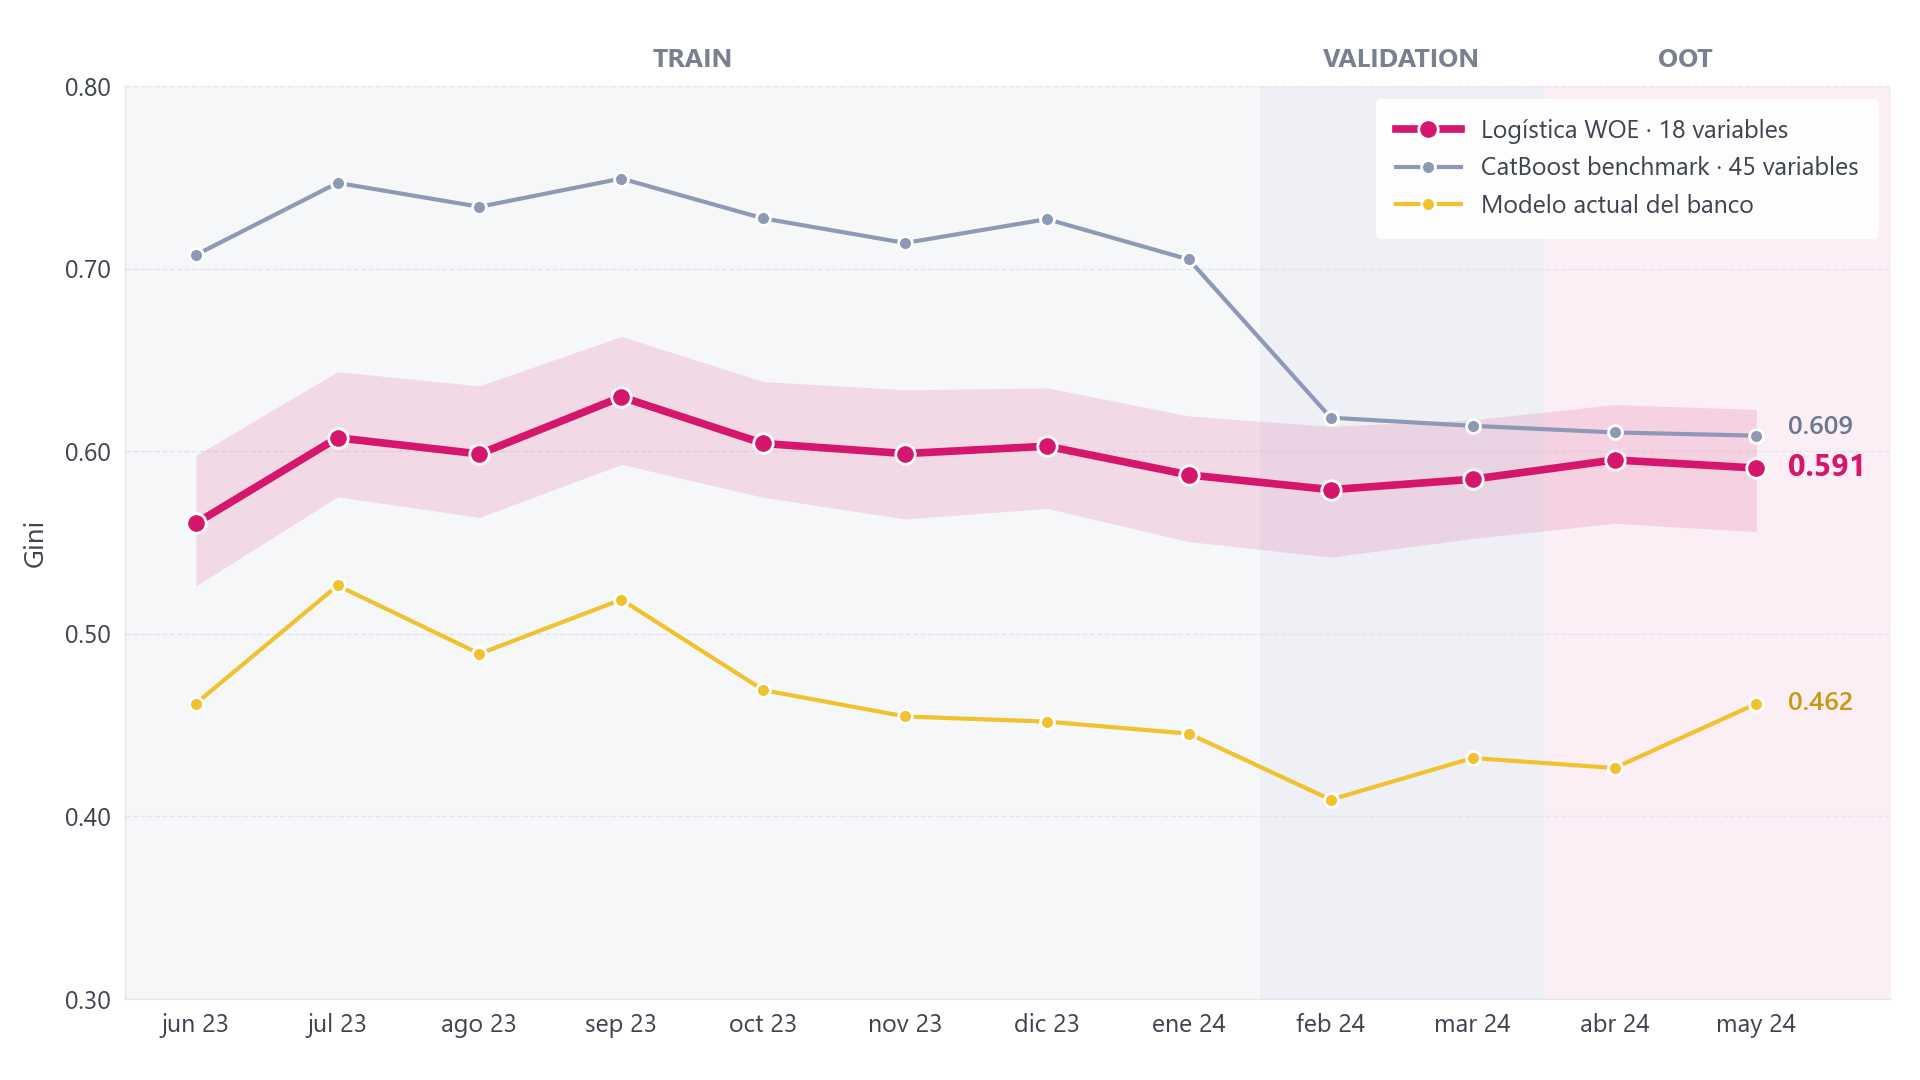

In [8]:
MESES = {1: "ene", 2: "feb", 3: "mar", 4: "abr", 5: "may", 6: "jun",
         7: "jul", 8: "ago", 9: "sep", 10: "oct", 11: "nov", 12: "dic"}
TEXTO, GRIS, GRID = "#3F4451", "#7A8090", "#E3E5EA"
# modelo: (leyenda, color de línea, color del texto, grosor, tamaño del marcador)
ESTILO = {
    "woe":      ("Logística WOE · 18 variables", "#D6156C", "#D6156C", 5.5, 14),
    "catboost": ("CatBoost benchmark · 45 variables", "#8E9AB5", "#6B7794", 3, 10),
    "banco":    ("Modelo actual del banco", "#F2C12E", "#C99A0E", 3, 10),
}
ZONAS = {"TRAIN": "#F6F7F9", "VALIDATION": "#EEF0F5", "OOT": "#FBEEF4"}

plt.rcParams.update({"font.family": ["Segoe UI", "DejaVu Sans"], "axes.spines.top": False,
                     "axes.spines.right": False, "axes.edgecolor": GRID})

t = gini_mensual
x = np.arange(len(t))
x_max = x[-1] + 0.95  # espacio para la etiqueta del último punto
fig, ax = plt.subplots(figsize=(19.2, 10.8), dpi=100, facecolor="white")
fig.subplots_adjust(left=0.065, right=0.985, top=0.92, bottom=0.075)

# Zonas TRAIN / VALIDATION / OOT con etiqueta arriba
arriba = blended_transform_factory(ax.transData, ax.transAxes)
for muestra, color in ZONAS.items():
    xs = x[t["muestra"] == muestra]
    a, b = xs.min() - 0.5, xs.max() + 0.5
    ax.axvspan(a, x_max if muestra == "OOT" else b, color=color, lw=0, zorder=0)
    ax.text((a + b) / 2, 1.015, muestra, transform=arriba, ha="center", va="bottom",
            fontsize=19, fontweight="bold", color=GRIS)

# Banda bootstrap solo para la logística WOE
ax.fill_between(x, t["gini_woe_ic95_inf"], t["gini_woe_ic95_sup"], color=ESTILO["woe"][1], alpha=0.13, lw=0, zorder=2)

lineas = {}
for m in ["banco", "catboost", "woe"]:  # la WOE al final para que quede encima
    nombre, color, _, grosor, marcador = ESTILO[m]
    lineas[m], = ax.plot(x, t[f"gini_{m}"], color=color, lw=grosor, marker="o", ms=marcador,
                         mec="white", mew=2, label=nombre, zorder=5 if m == "woe" else 4)

# Etiqueta solo en el último punto; se separan si quedan a menos de 0.022
ultimos = sorted((t[f"gini_{m}"].iat[-1], m) for m in MODELOS)
y_etiqueta = {}
for i, (v, m) in enumerate(ultimos):
    y_etiqueta[m] = max(v, y_etiqueta[ultimos[i - 1][1]] + 0.022) if i else v
for v, m in ultimos:
    ax.text(x[-1] + 0.22, y_etiqueta[m], f"{v:.3f}", ha="left", va="center", color=ESTILO[m][2],
            fontsize=22 if m == "woe" else 19, fontweight="bold" if m == "woe" else "semibold")

ax.set_xlim(-0.5, x_max)
ax.set_xticks(x, [f"{MESES[c % 100]} {str(c // 100)[2:]}" for c in t["CODMES"]])
ax.set_ylim(0.30, 0.80)
ax.set_yticks(np.arange(0.30, 0.801, 0.10))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.2f}")
ax.tick_params(axis="both", labelsize=18, colors=TEXTO, length=0, pad=10)
ax.set_ylabel("Gini", fontsize=20, color=TEXTO, labelpad=12)
ax.grid(axis="y", color=GRID, lw=1, ls="--", zorder=1)
ax.set_axisbelow(True)
leyenda = ax.legend([lineas[m] for m in MODELOS], [ESTILO[m][0] for m in MODELOS], loc="upper right",
                    fontsize=18, frameon=True, facecolor="white", edgecolor="none", framealpha=0.92,
                    borderpad=0.8, handlelength=2.6)
for texto in leyenda.get_texts():
    texto.set_color(TEXTO)

RUTA_PNG = OUT_DIR / "gini_mensual.png"
fig.savefig(RUTA_PNG, dpi=100, facecolor="white")  # sin bbox_inches para mantener 1920x1080 exacto
plt.close(fig)
display(Image(filename=str(RUTA_PNG), width=960))

## 8. Resumen

In [9]:
NOMBRE = {"woe": "Logística WOE", "catboost": "CatBoost", "banco": "Modelo actual"}
mes = lambda c: f"{MESES[c % 100]} {str(c // 100)[2:]}"

lineas_resumen = ["Gini mensual (jun 23 – may 24)"]
for m in MODELOS:
    g = t.set_index("CODMES")[f"gini_{m}"]
    lineas_resumen.append(f"- {NOMBRE[m]}: mín {g.min():.3f} ({mes(g.idxmin())}), máx {g.max():.3f} "
                          f"({mes(g.idxmax())}), rango {(g.max() - g.min()) * 100:.1f} pts")

debajo = t.loc[t["gini_woe"] < t["gini_banco"], "CODMES"]
lineas_resumen.append("- Meses con la logística WOE por debajo del modelo actual: "
                      + (", ".join(mes(c) for c in debajo) if len(debajo) else "ninguno (12 de 12 por encima)"))

oot = t[t["muestra"] == "OOT"]
lineas_resumen.append(f"- Brecha promedio OOT (abr–may 24), WOE − modelo actual: "
                      f"{(oot['gini_woe'] - oot['gini_banco']).mean() * 100:+.1f} pts")
lineas_resumen.append(f"- Brecha promedio OOT (abr–may 24), WOE − CatBoost: "
                      f"{(oot['gini_woe'] - oot['gini_catboost']).mean() * 100:+.1f} pts")

agregado = verificacion.pivot(index="modelo", columns="muestra", values="gini").loc[MODELOS, MUESTRAS]
lineas_resumen.append("\nGini agregado por muestra (tarjetas del slide)")
for m in MODELOS:
    lineas_resumen.append(f"- {NOMBRE[m]}: " + " | ".join(f"{s} {agregado.loc[m, s]:.3f}" for s in MUESTRAS))
print("\n".join(lineas_resumen))

Gini mensual (jun 23 – may 24)
- Logística WOE: mín 0.561 (jun 23), máx 0.630 (sep 23), rango 6.9 pts
- CatBoost: mín 0.609 (may 24), máx 0.750 (sep 23), rango 14.1 pts
- Modelo actual: mín 0.409 (feb 24), máx 0.527 (jul 23), rango 11.7 pts
- Meses con la logística WOE por debajo del modelo actual: ninguno (12 de 12 por encima)
- Brecha promedio OOT (abr–may 24), WOE − modelo actual: +14.9 pts
- Brecha promedio OOT (abr–may 24), WOE − CatBoost: -1.6 pts

Gini agregado por muestra (tarjetas del slide)
- Logística WOE: TRAIN 0.599 | VALIDATION 0.582 | OOT 0.593
- CatBoost: TRAIN 0.726 | VALIDATION 0.616 | OOT 0.609
- Modelo actual: TRAIN 0.476 | VALIDATION 0.420 | OOT 0.445
